<a href="https://colab.research.google.com/github/olawaleaboderin/AVCAD/blob/main/Exercise7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as sts
import seaborn as sns
import matplotlib.pyplot as plt
import statistics as stat

In [2]:
# Load dataset
df = pd.read_csv(
    'https://raw.githubusercontent.com/olawaleaboderin/greends-avcad-2026/main/examples/EFIplus_medit.zip',
    sep=";"
)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (5011, 164)


,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


## Question 1: Check visually if any of the continuous environmental variables in the EFIplus_medit dataset (Altitude, Actual_river_slope, Elevation_mean_catch, prec_ann_catch, temp_ann, temp_jan, temp_jul) would require a data transformation in order to apply parametric tests.


Distribution of Environmental Variables


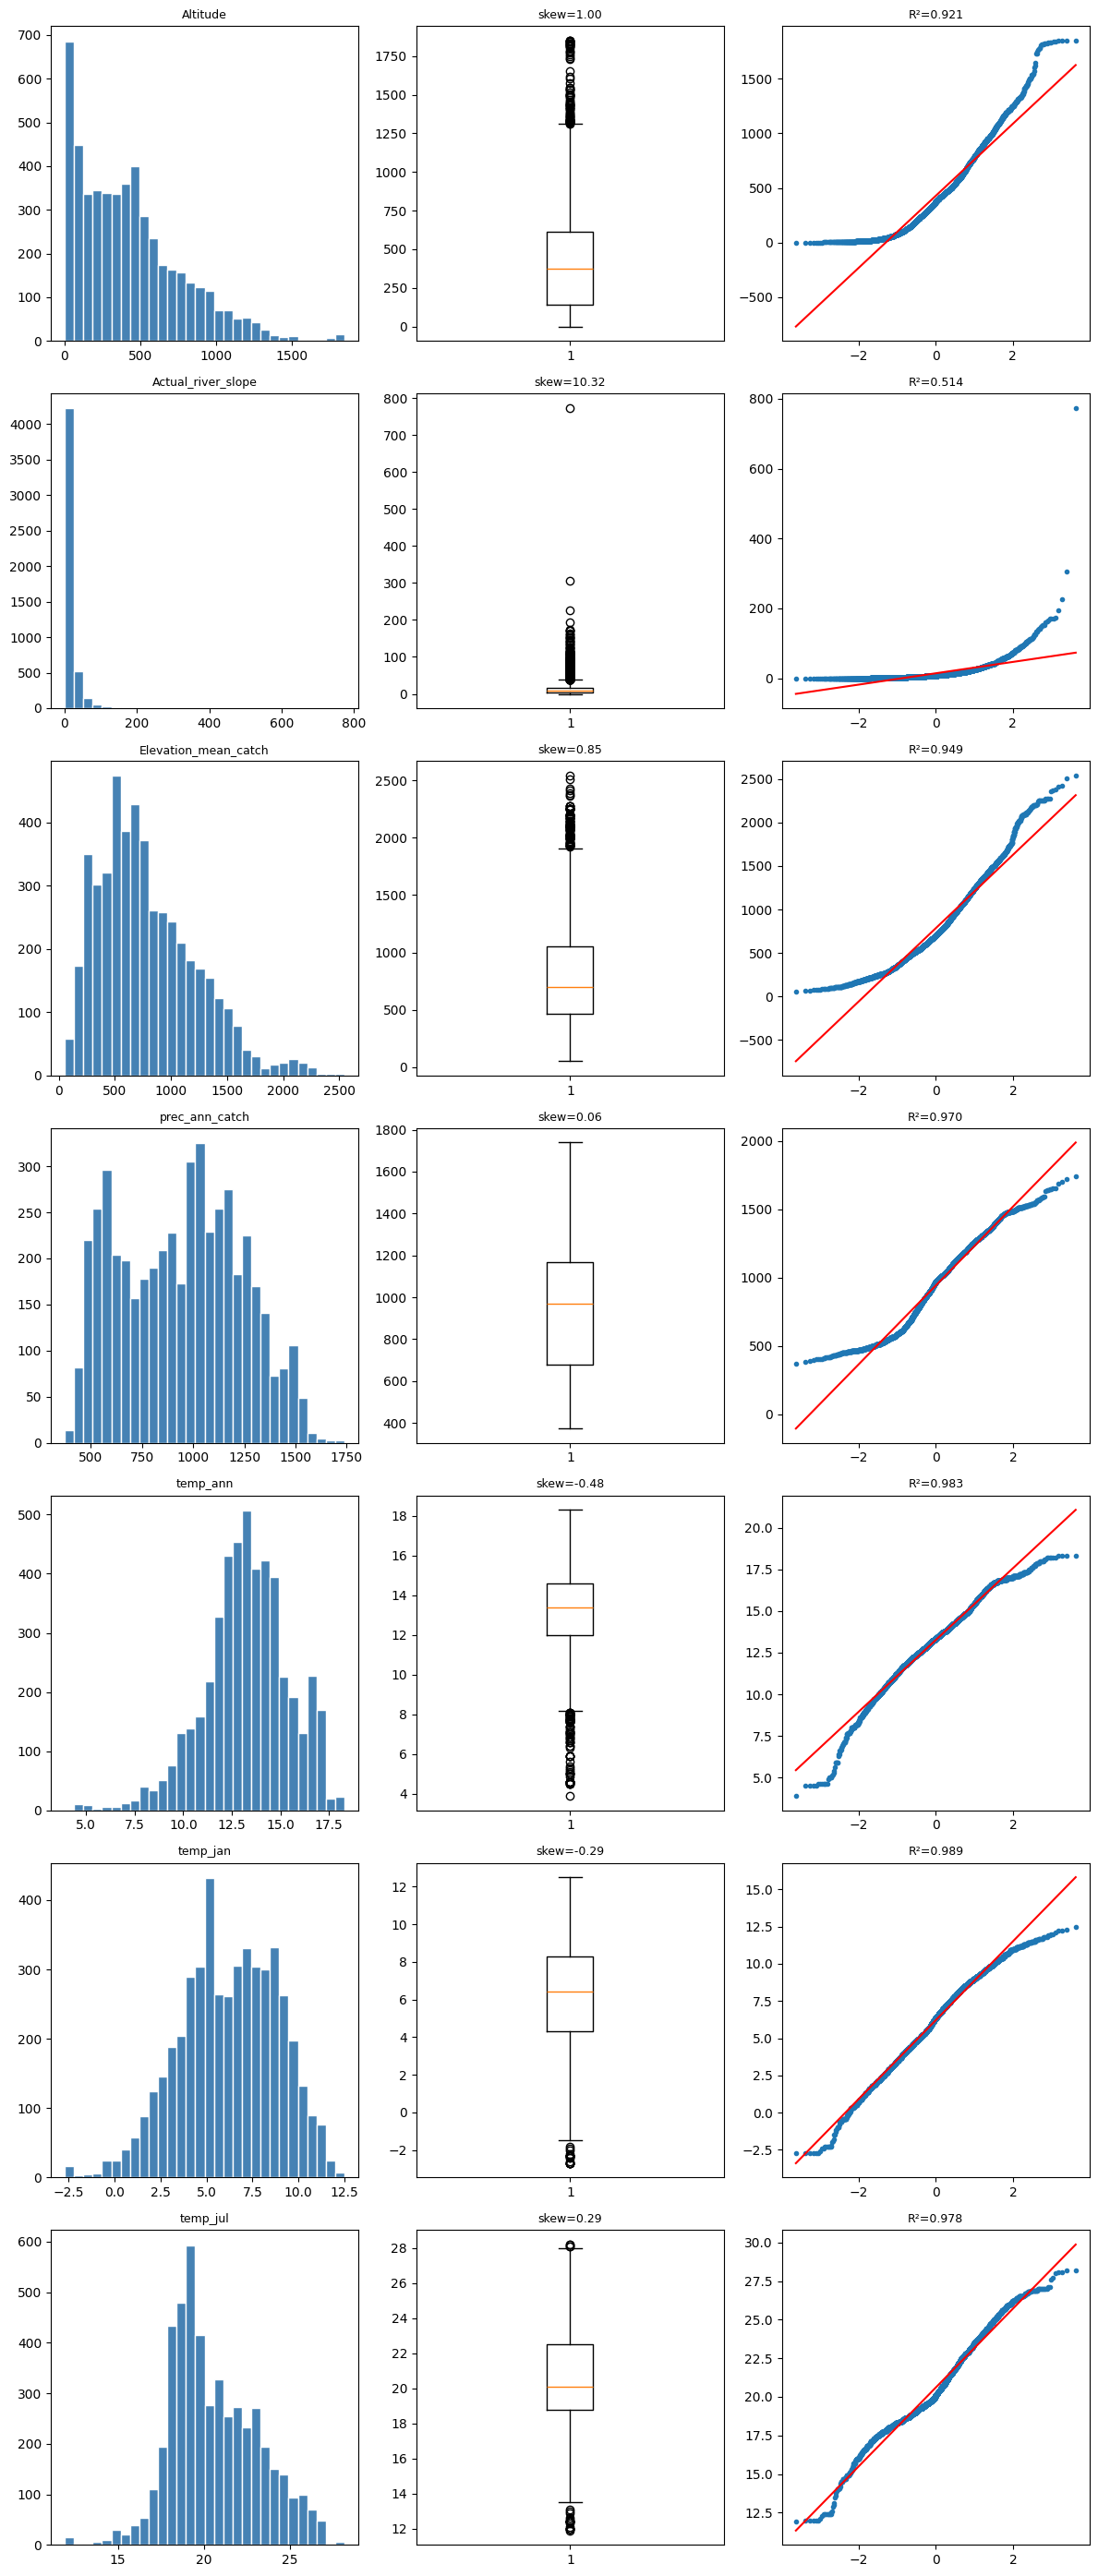

In [4]:
plt.style.use('default')

env_vars = ['Altitude', 'Actual_river_slope', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul']

print("\n" + "="*60)
print("Distribution of Environmental Variables")
print("="*60)

fig, axes = plt.subplots(len(env_vars), 3, figsize=(12, 4 * len(env_vars)))
axes[0, 0].set_title('Histogram')
axes[0, 1].set_title('Boxplot')
axes[0, 2].set_title('Q-Q Plot')

for i, var in enumerate(env_vars):
    col = df[var].dropna()

    # Histogram
    ax_hist = axes[i, 0]
    ax_hist.hist(col, bins=30, color='steelblue', edgecolor='white')
    ax_hist.set_title(f'{var}', fontsize=9)

    # Boxplot
    ax_box = axes[i, 1]
    ax_box.boxplot(col, vert=True)
    skew = col.skew()
    ax_box.set_title(f'skew={skew:.2f}', fontsize=9)

    # Q-Q plot
    ax_qq = axes[i, 2]
    (osm, osr), (slope, intercept, r) = sts.probplot(col, dist="norm")
    ax_qq.plot(osm, osr, 'o', markersize=3)
    ax_qq.plot(osm, slope * np.array(osm) + intercept, 'r-')
    ax_qq.set_title(f'R²={r**2:.3f}', fontsize=9)

plt.tight_layout()
plt.show()

From the visual inspection of the plots:
Altitude, Actual_river_slope, Elevation_mean_catch, and prec_ann_catch show clear right-skewed distributions. Their Q-Q plots deviate significantly from the red line, indicating non-normal behavior.

In contrast, temp_ann, temp_jan, and temp_jul appear more symmetric, with slight deviaitons observed on their Q-Q plots still show some deviations.
Therefore, to apply parametric tests, data transformation for  Altitude, Actual_river_slope, Elevation_mean_catch, and prec_ann_catch would be necessary.

## Question 2: Apply the appropriate data transformation and check the new distributions.


Distribution of Transformed Environmental Variables


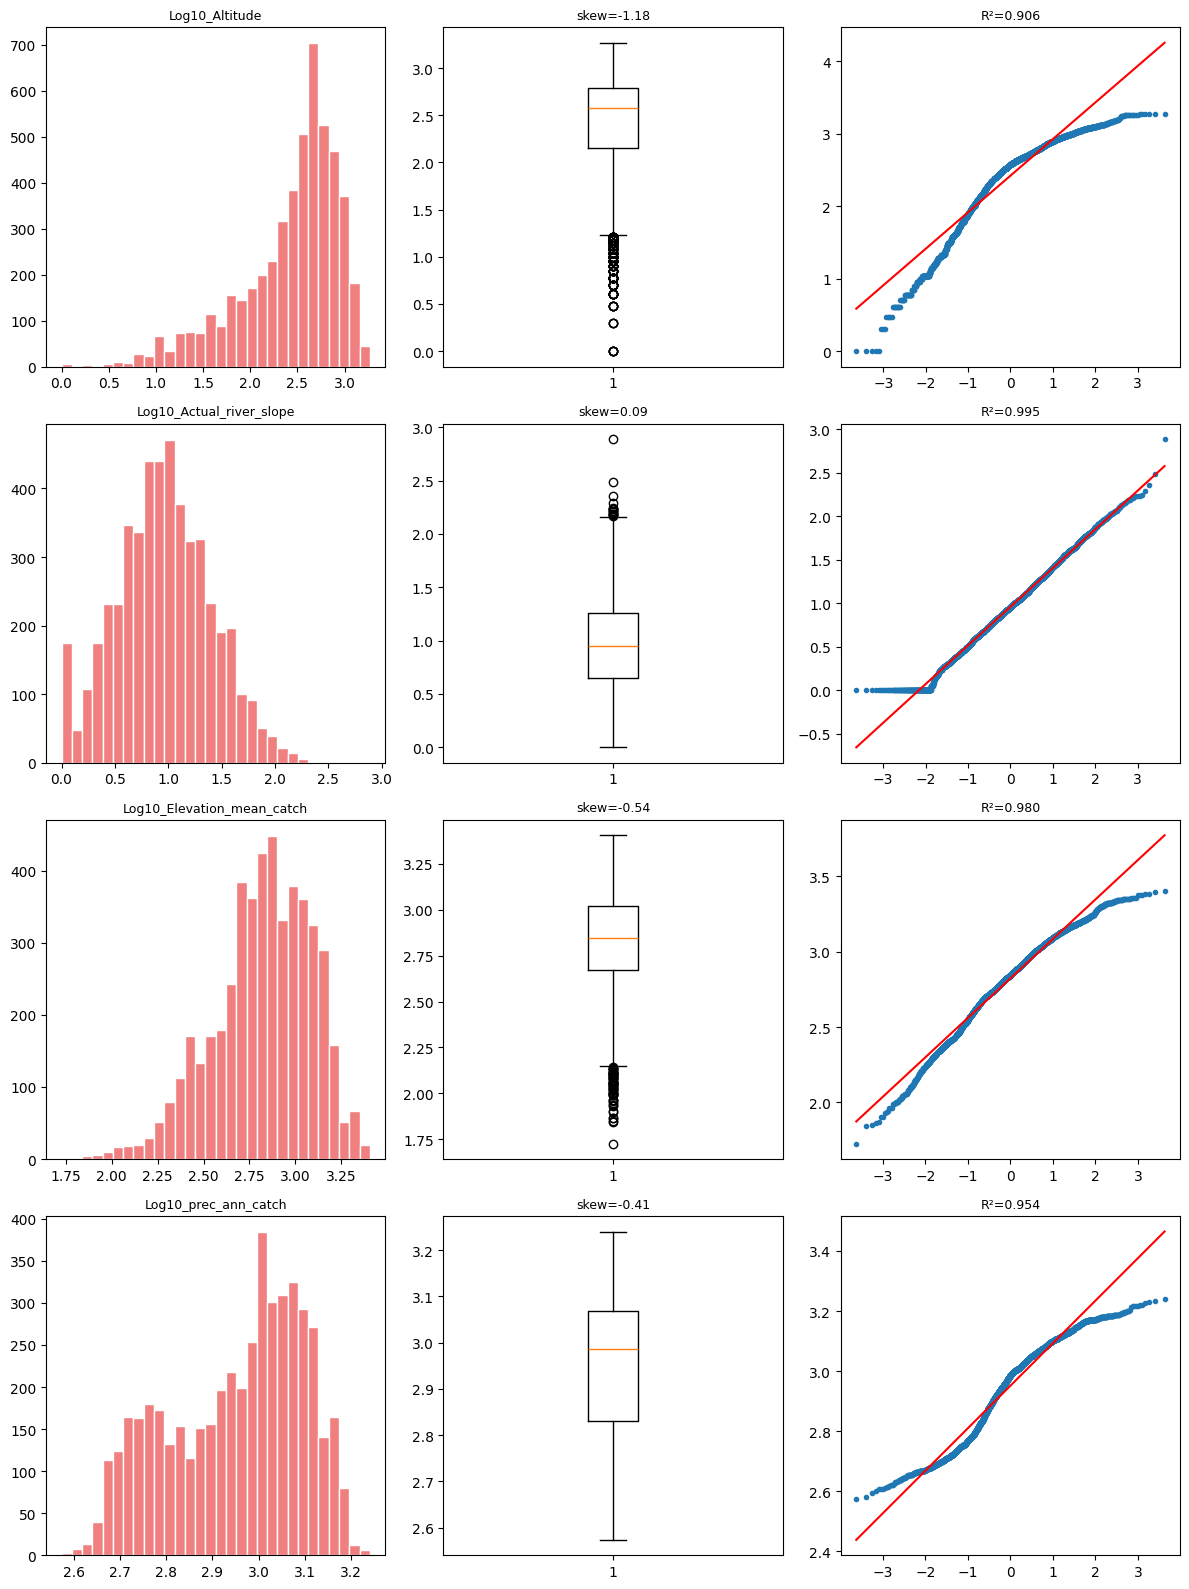

In [6]:
print("\n" + "="*60)
print("Distribution of Transformed Environmental Variables")
print("="*60)

# Define the variables to be transformed based on the previous visual inspection
vars_to_transform_log10 = ['Altitude', 'Actual_river_slope', 'Elevation_mean_catch', 'prec_ann_catch']

transformed_env_vars_log10 = [f'Log10_{var}' for var in vars_to_transform_log10]

# Apply log10 transformation to the specified variables and create new columns
for var in vars_to_transform_log10:
    # Add 1 to handle zero values before applying log10
    df[f'Log10_{var}'] = np.log10(df[var] + 1)

fig, axes = plt.subplots(len(transformed_env_vars_log10), 3, figsize=(12, 4 * len(transformed_env_vars_log10)))

# Ensure axes is always a 2D array, even if there's only one variable
if len(transformed_env_vars_log10) == 1:
    axes = np.expand_dims(axes, axis=0)

axes[0, 0].set_title('Histogram')
axes[0, 1].set_title('Boxplot')
axes[0, 2].set_title('Q-Q Plot')

for i, var in enumerate(transformed_env_vars_log10):
    col = df[var].dropna()

    # Histogram
    ax_hist = axes[i, 0]
    ax_hist.hist(col, bins=30, color='lightcoral', edgecolor='white')
    ax_hist.set_title(f'{var}', fontsize=9)

    # Boxplot
    ax_box = axes[i, 1]
    ax_box.boxplot(col, vert=True)
    skew = col.skew()
    ax_box.set_title(f'skew={skew:.2f}', fontsize=9)

    # Q-Q plot
    ax_qq = axes[i, 2]
    (osm, osr), (slope, intercept, r) = sts.probplot(col, dist="norm")
    ax_qq.plot(osm, osr, 'o', markersize=3)
    ax_qq.plot(osm, slope * np.array(osm) + intercept, 'r-')
    ax_qq.set_title(f'R²={r**2:.3f}', fontsize=9)

plt.tight_layout()
plt.show()

The plots for the transformed variables (Histograms, Boxplots, and Q-Q Plots) generally show an improvement in their distributions compared to the original variables. The histograms appear more symmetric, the boxplots indicate reduced skewness, and the points on the Q-Q plots lie closer to the red diagonal line, suggesting a better approximation of a normal distribution.

## Question 3: Create a column with the total number of species present (the species richness) in each sampling site (NOTE: the first species in the dataset is ‘Abramis brama’ and all the columns to the right correspond to species presence/absence).

In [7]:

# Identify the starting column for species data
species_start_col_index = df.columns.get_loc('Abramis brama')

# Select only true species columns (exclude Log10_ transformations and species_richness)
species_cols = [col for col in df.columns[species_start_col_index:]
                if col != 'species_richness' and not col.startswith('Log10_')]

# Calculate species richness (sum of presence/absence per row)
df['species_richness'] = df[species_cols].sum(axis=1)

# Sanity check
print('Species columns used:', len(species_cols))
print('Max richness:', df['species_richness'].max())
print('Unique values in species columns:', pd.unique(df[species_cols].values.ravel()))

# Summary
print('\nDescriptive statistics for species_richness:')
print(df['species_richness'].describe())

# Show result
print('\nFirst 10 rows:')
print(df[['Site_code', 'species_richness']].head(10))


Species columns used: 108
Max richness: 29
Unique values in species columns: [0 1]

Descriptive statistics for species_richness:
count    5011.000000
mean        3.508481
std         2.879080
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max        29.000000
Name: species_richness, dtype: float64

First 10 rows:
    Site_code  species_richness
0  ES_01_0002                 1
1  ES_02_0001                 1
2  ES_02_0002                 1
3  ES_02_0003                 2
4  ES_02_0004                 2
5  ES_02_0005                 4
6  ES_02_0006                 4
7  ES_02_0007                 6
8  ES_02_0008                 4
9  ES_02_0010                 1


## Question 4: Check the existence of bivariate outliers in the relationship between Mean Annual Temperature (‘temp_ann’) and species richness using an appropriate plot. Run a bivariate isolation forest to detect outliers and plot the result.

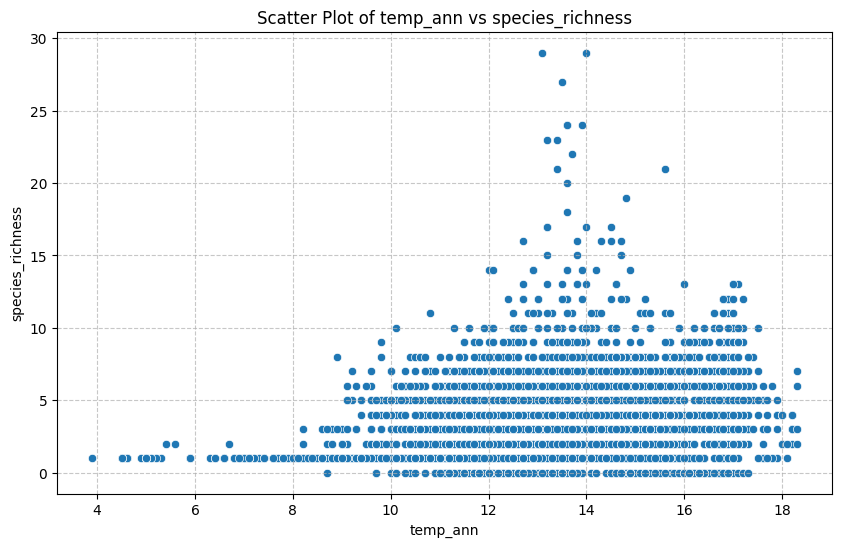

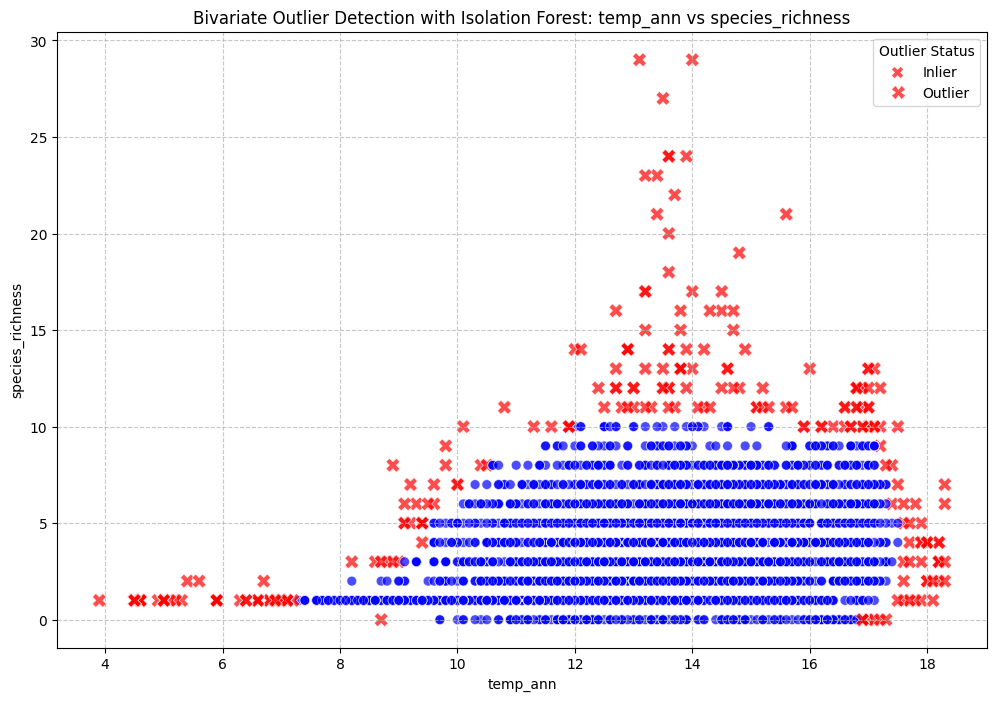

Total sites analysed : 4841
Inliers  (1)         : 4604
Outliers (-1)        : 237


In [8]:
from sklearn.ensemble import IsolationForest

# Define the variables for analysis
x_var = 'temp_ann'
y_var = 'species_richness'

# Drop rows with NaN values in the selected columns for cleaner analysis
df_filtered = df[[x_var, y_var]].dropna()

# Visualize the relationship with a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x=x_var, y=y_var)
plt.title(f'Scatter Plot of {x_var} vs {y_var}')
plt.xlabel(x_var)
plt.ylabel(y_var)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 1. Run a bivariate Isolation Forest to detect outliers
# Initialize the Isolation Forest model
# n_estimators: The number of base estimators in the ensemble.
# contamination: The proportion of outliers in the dataset. 'auto' tries to estimate it.
# random_state: For reproducibility
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

# Fit the model and predict outliers
# -1 for outliers, 1 for inliers
outlier_labels = iso_forest.fit_predict(df_filtered[[x_var, y_var]])

# Add the outlier labels to the filtered DataFrame
df_filtered['outlier'] = outlier_labels

# 2. Plot the result, highlighting the detected outliers
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_filtered,
    x=x_var,
    y=y_var,
    hue='outlier', # Color points based on whether they are outliers
    palette={1: 'blue', -1: 'red'}, # Blue for inliers, Red for outliers
    style='outlier', # Different markers for inliers/outliers
    markers={1: 'o', -1: 'X'}, # Circle for inliers, 'X' for outliers
    size='outlier', # Different sizes for inliers/outliers
    sizes={1: 50, -1: 100}, # Larger size for outliers
    alpha=0.7
)
plt.title(f'Bivariate Outlier Detection with Isolation Forest: {x_var} vs {y_var}')
plt.xlabel(x_var)
plt.ylabel(y_var)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Outlier Status', labels=['Inlier', 'Outlier'])
plt.show()

n_outliers = (df_filtered['outlier'] == -1).sum()
n_inliers  = (df_filtered['outlier'] ==  1).sum()
print(f'Total sites analysed : {len(df_filtered)}')
print(f'Inliers  (1)         : {n_inliers}')
print(f'Outliers (-1)        : {n_outliers}')

The scatter plot reveals a non-linear relationship between mean annual temperature and species richness. Species richness tends to peak at intermediate temperatures (around 13–14°C) and is lower at both cold and warm extremes. Several points appear to sit far from the main cloud, particularly sites with unusually high species richness relative to their temperature, suggesting the presence of bivariate outliers.

The Isolation Forest algorithm identified a notable number of outlier sites (shown in red). These outliers are mostly concentrated at two extremes — sites with very high species richness regardless of temperature, and cold sites (below 8°C) with any species present. These represent unusual temperature–richness combinations that deviate from the general pattern observed in the dataset.

## Question 5: Explore visually, using a single plot, if this relationship (temp_ann x species richness) may vary across countries.

<Figure size 1400x800 with 0 Axes>

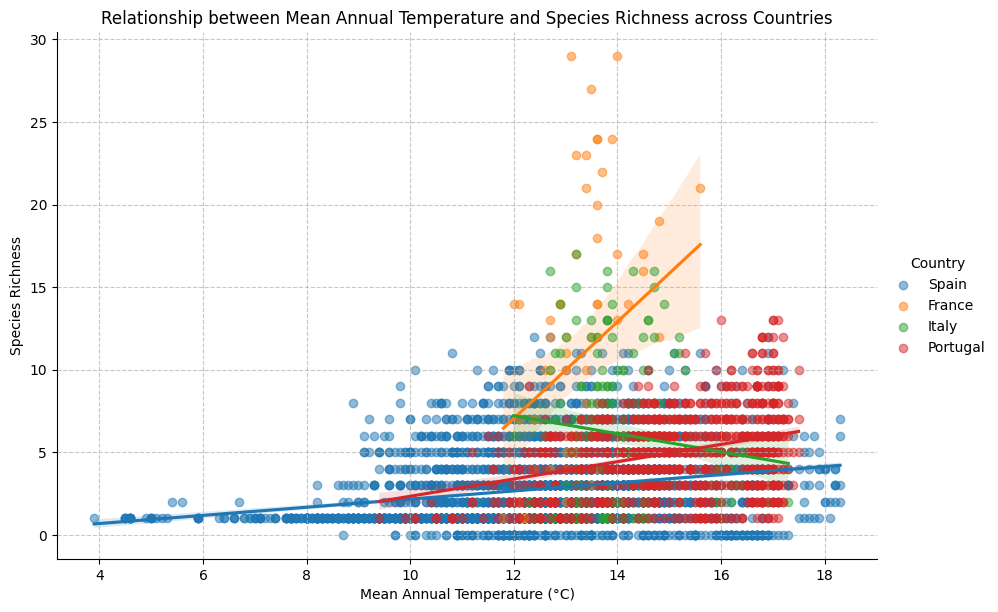

In [9]:
plt.figure(figsize=(14, 8))
sns.lmplot(data=df, x='temp_ann', y='species_richness', hue='Country', height=6, aspect=1.5, scatter_kws={'alpha':0.5})
plt.title('Relationship between Mean Annual Temperature and Species Richness across Countries')
plt.xlabel('Mean Annual Temperature (°C)')
plt.ylabel('Species Richness')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The lmplot reveals that the relationship between mean annual temperature and species richness varies considerably across countries. Portugal, Spain, and France show positive relationships, with France displaying the strongest positive trend, where species richness increases more steeply with temperature. In contrast, Italy shows a negative slope, implying that species richness tends to decrease as mean annual temperature increases.